# IndPenSim Dataset — Overview & EDA

**목적**: 100배치 페니실린 발효 공정 시뮬레이션 데이터에 대한 탐색적 분석  
**데이터**: `100_Batches_IndPenSim_V3.csv` (시계열), `100_Batches_IndPenSim_Statistics.csv` (배치 요약)  

---
**분석 순서**
1. 라이브러리 및 데이터 로드
2. 데이터 기본 구조 확인
3. 배치 통계 분석 (Fault 비율, 수율 분포)
4. 공정 변수 시계열 탐색
5. 라만 분광 데이터 탐색
6. 결측치 분석
7. Fault vs Normal 배치 비교
8. 요약 및 연구 방향

## 1. 라이브러리 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_DIR    = Path('../data/raw')
STATS_PATH  = DATA_DIR / '100_Batches_IndPenSim_Statistics.csv'
MAIN_PATH   = DATA_DIR / '100_Batches_IndPenSim_V3.csv'
RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures'

BATCH_COL       = 'Batch reference(Batch_ref:Batch ref)'
BATCH_NUM_COL   = 'batch_number'
BATCH_COL_STATS = 'Batch ref'
FAULT_COL       = 'Fault ref(0-NoFault 1-Fault)'
PAT_COL         = '2-PAT control(PAT_ref:PAT ref)'
TIME_COL        = 'Time (h)'
YIELD_COL       = 'Penicllin_yield_total (kg)'

In [2]:
df_stats = pd.read_csv(STATS_PATH)
df_stats.columns = df_stats.columns.str.strip()
print('Statistics shape:', df_stats.shape)
df_stats.head()

Statistics shape: (100, 5)


,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
0,1,1066400.0,1720000.0,2786400.0,0
1,2,985910.0,1340100.0,2326000.0,0
2,3,1416100.0,1259200.0,2675300.0,0
3,4,815700.0,1071000.0,1886700.0,0
4,5,1128500.0,2434400.0,3562900.0,0


In [3]:
# 대용량 파일 — 메모리 최적화 로드 (수십 초 소요)
_header   = pd.read_csv(MAIN_PATH, nrows=0)
_all_cols = _header.columns.str.strip().tolist()
_raman_tmp = [c for c in _all_cols if c.strip().lstrip('-').isdigit()]

_dtype_map = {col: 'float32' for col in _raman_tmp}
# PAT_COL('2-PAT control')은 배치 번호(1~100)를 저장하므로 Int8 불필요
if FAULT_COL in _all_cols:
    _dtype_map[FAULT_COL] = 'Int8'

df = pd.read_csv(MAIN_PATH, dtype=_dtype_map, low_memory=False)
df.columns = df.columns.str.strip()

# 배치 번호 생성 — Batch reference 컬럼은 이진 플래그(0/1)라 사용 불가
# Time (h)가 감소(리셋)하는 지점을 새 배치 시작으로 탐지
_time_diff  = df[TIME_COL].diff()
_reset_mask = _time_diff.fillna(0) < 0
df[BATCH_NUM_COL] = (_reset_mask.cumsum() + 1).astype(int)

# 결과 저장 경로 생성
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print('Main data shape:', df.shape)
print(f'배치 수        : {df[BATCH_NUM_COL].nunique()}')
print(f'메모리 사용    : {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB')
df.head(3)

C:\Users\Admin\AppData\Local\Temp\ipykernel_12340\4273928868.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[BATCH_NUM_COL] = (_reset_mask.cumsum() + 1).astype(int)


Main data shape: (113935, 2240)
배치 수        : 100
메모리 사용    : 991 MB


,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,209,208,207,206,205,204,203,202,201,batch_number
0,0.2,30,100,8,0.0,30.118,9.8335,0.0001,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
1,0.4,30,100,8,0.0,51.221,18.1550,0.0001,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1
2,0.6,30,100,8,0.0,54.302,9.5982,0.0001,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1


## 2. 데이터 기본 구조 확인

In [4]:
raman_cols   = [c for c in df.columns if c.strip().lstrip('-').isdigit()]
process_cols = [c for c in df.columns if c not in raman_cols and c != BATCH_NUM_COL]

print(f'전체 컬럼 수      : {df.shape[1]}')
print(f'공정 변수 수      : {len(process_cols)}')
print(f'라만 분광 채널 수  : {len(raman_cols)}')
print(f'라만 웨이브넘버    : {min(int(c) for c in raman_cols)} ~ {max(int(c) for c in raman_cols)} cm⁻¹')
print()
print('공정 변수 목록:')
for i, c in enumerate(process_cols):
    print(f'  [{i:2d}] {c}')

전체 컬럼 수      : 2240
공정 변수 수      : 39
라만 분광 채널 수  : 2200
라만 웨이브넘버    : 201 ~ 2400 cm⁻¹

공정 변수 목록:
  [ 0] Time (h)
  [ 1] Aeration rate(Fg:L/h)
  [ 2] Agitator RPM(RPM:RPM)
  [ 3] Sugar feed rate(Fs:L/h)
  [ 4] Acid flow rate(Fa:L/h)
  [ 5] Base flow rate(Fb:L/h)
  [ 6] Heating/cooling water flow rate(Fc:L/h)
  [ 7] Heating water flow rate(Fh:L/h)
  [ 8] Water for injection/dilution(Fw:L/h)
  [ 9] Air head pressure(pressure:bar)
  [10] Dumped broth flow(Fremoved:L/h)
  [11] Substrate concentration(S:g/L)
  [12] Dissolved oxygen concentration(DO2:mg/L)
  [13] Penicillin concentration(P:g/L)
  [14] Vessel Volume(V:L)
  [15] Vessel Weight(Wt:Kg)
  [16] pH(pH:pH)
  [17] Temperature(T:K)
  [18] Generated heat(Q:kJ)
  [19] carbon dioxide percent in off-gas(CO2outgas:%)
  [20] PAA flow(Fpaa:PAA flow (L/h))
  [21] PAA concentration offline(PAA_offline:PAA (g L^{-1}))
  [22] Oil flow(Foil:L/hr)
  [23] NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))
  [24] Oxygen Uptake Rate(OUR:(g min^{-

배치 수          : 100
타임스텝 수 (min) : 835
타임스텝 수 (max) : 1450
타임스텝 수 (mean): 1139.3


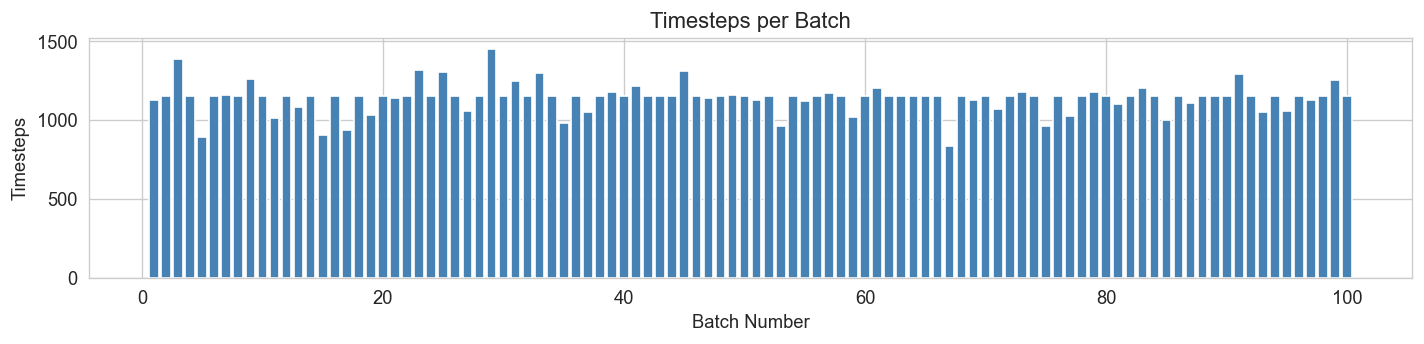

In [5]:
batch_lengths = df.groupby(BATCH_NUM_COL).size().sort_index()

print(f'배치 수          : {batch_lengths.shape[0]}')
print(f'타임스텝 수 (min) : {batch_lengths.min()}')
print(f'타임스텝 수 (max) : {batch_lengths.max()}')
print(f'타임스텝 수 (mean): {batch_lengths.mean():.1f}')

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(batch_lengths.index, batch_lengths.values, color='steelblue', width=0.8)
ax.set_xlabel('Batch Number')
ax.set_ylabel('Timesteps')
ax.set_title('Timesteps per Batch')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_batch_timesteps.png', bbox_inches='tight')
plt.show()

## 3. 배치 통계 분석

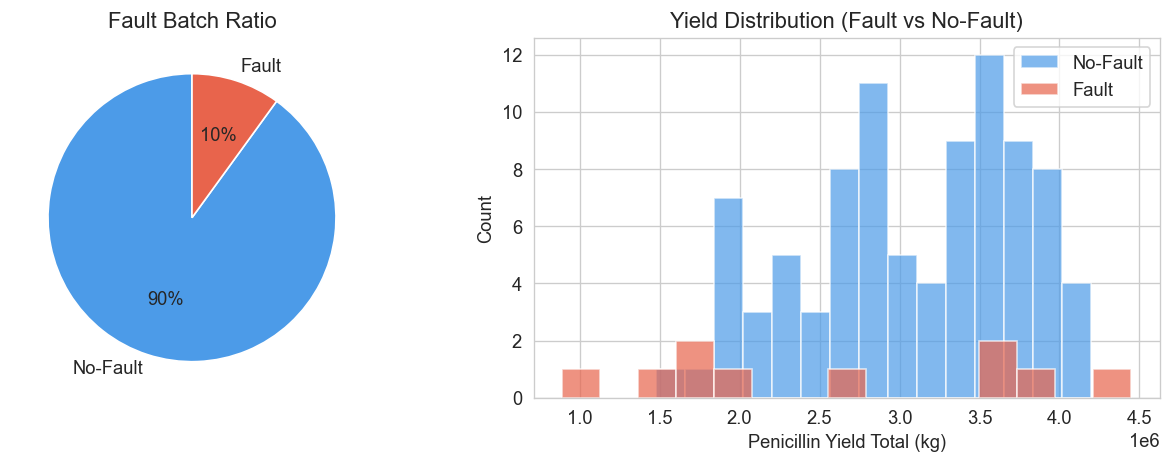

                              count       mean        std        min  \
Fault ref(0-NoFault 1-Fault)                                           
0                              90.0  3076716.0   677186.0  1474100.0   
1                              10.0  2600203.0  1199611.0   890830.0   

                                    25%        50%        75%        max  
Fault ref(0-NoFault 1-Fault)                                              
0                             2605650.0  3185000.0  3587850.0  4196000.0  
1                             1736100.0  2275950.0  3592275.0  4447700.0  


In [6]:
fault_counts = df_stats[FAULT_COL].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(
    fault_counts.values,
    labels=['No-Fault', 'Fault'],
    autopct='%1.0f%%',
    colors=['#4C9BE8', '#E8644C'],
    startangle=90
)
axes[0].set_title('Fault Batch Ratio')

for label, color in zip([0, 1], ['#4C9BE8', '#E8644C']):
    subset = df_stats[df_stats[FAULT_COL] == label][YIELD_COL]
    axes[1].hist(subset, bins=15, alpha=0.7, color=color,
                 label='No-Fault' if label == 0 else 'Fault')
axes[1].set_xlabel('Penicillin Yield Total (kg)')
axes[1].set_ylabel('Count')
axes[1].set_title('Yield Distribution (Fault vs No-Fault)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_yield_distribution.png', bbox_inches='tight')
plt.show()

print(df_stats.groupby(FAULT_COL)[YIELD_COL].describe().round(0))

## 4. 공정 변수 시계열 탐색

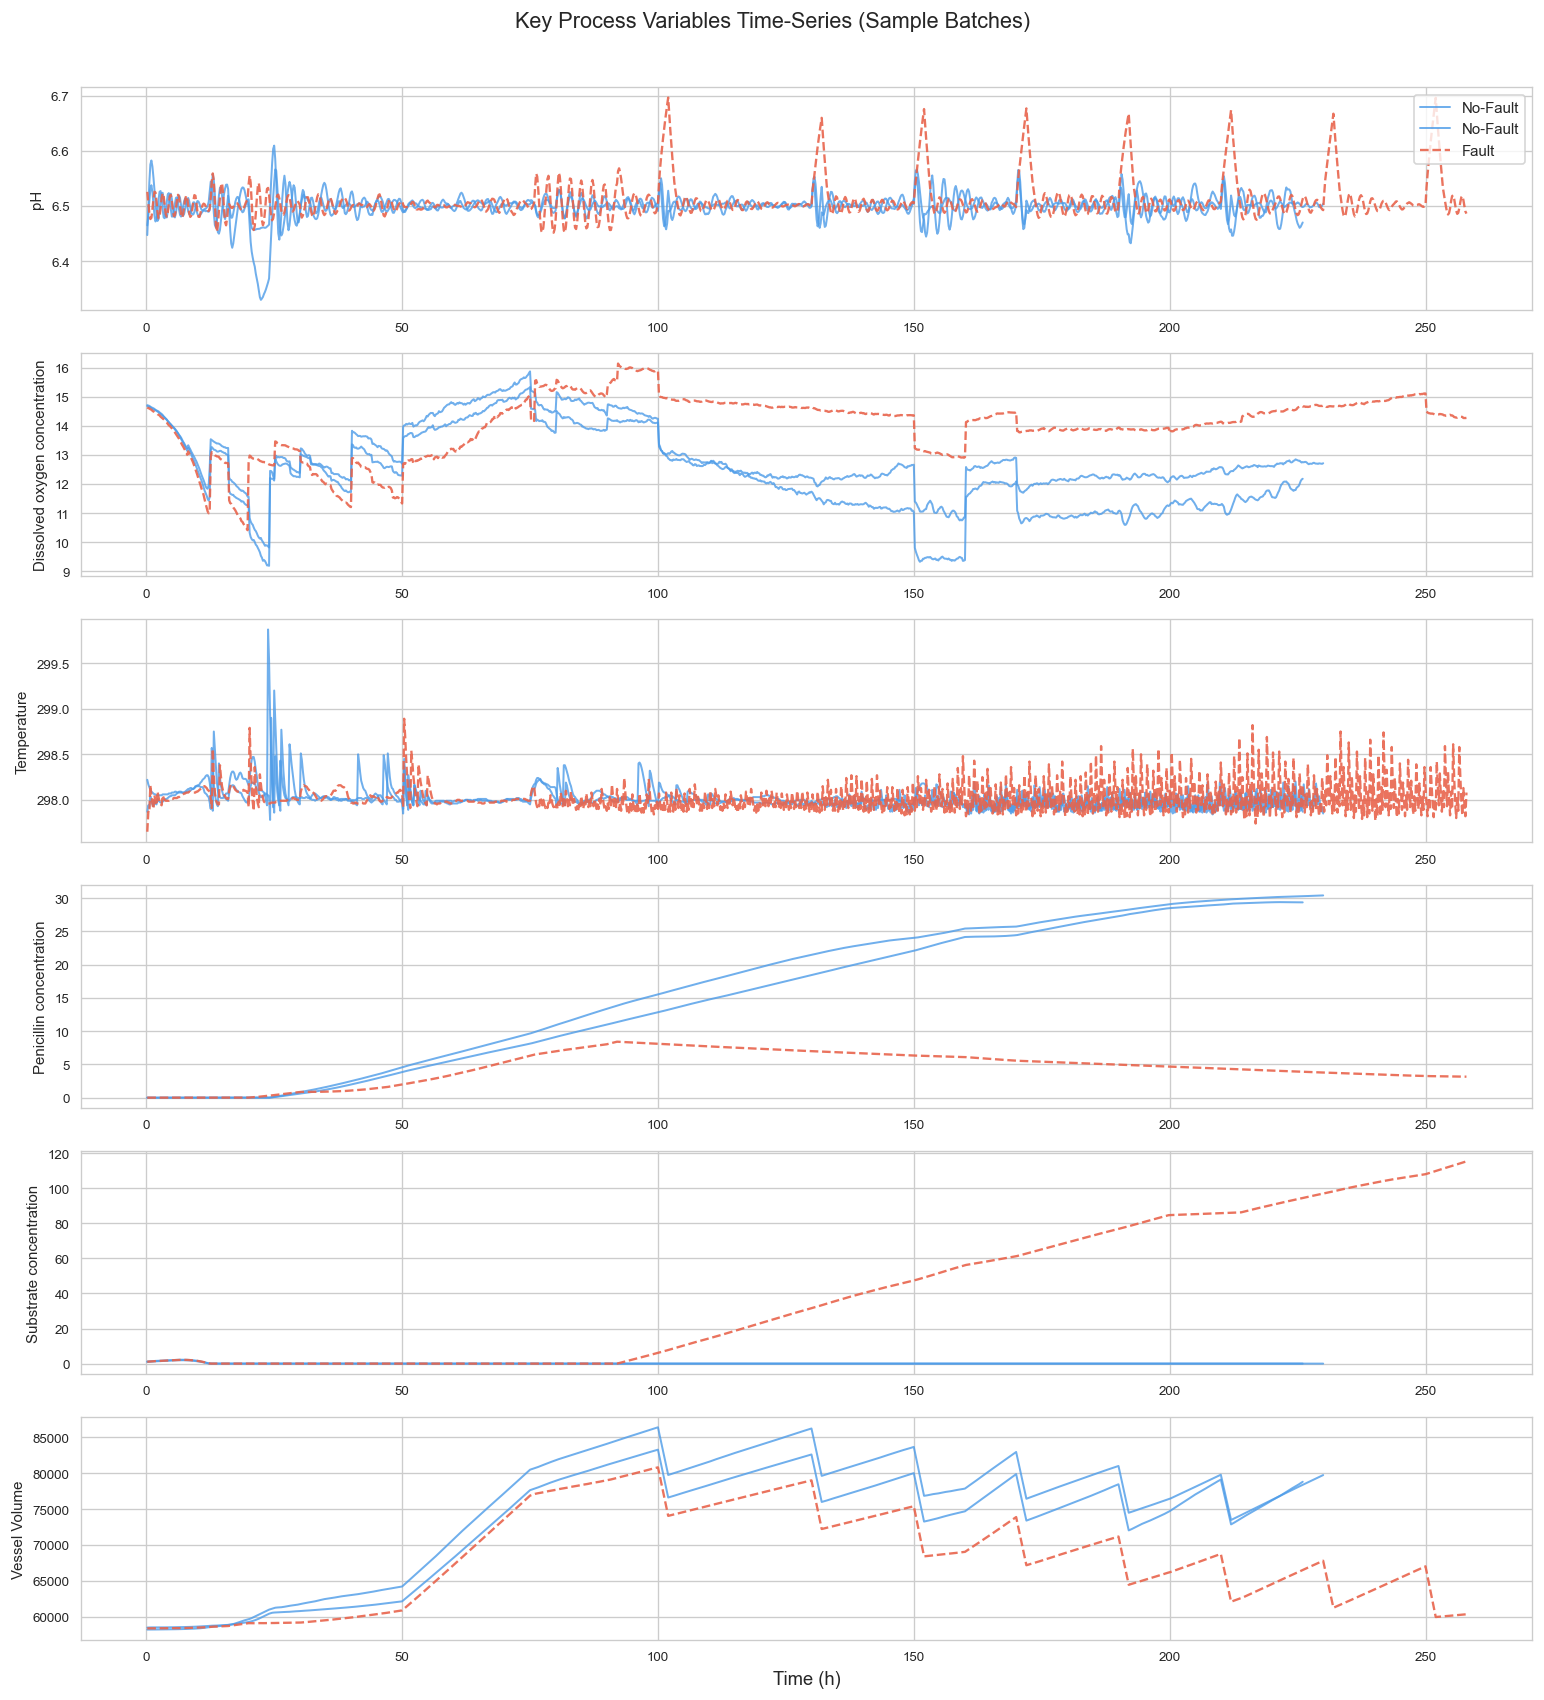

In [7]:
key_vars = [
    'pH(pH:pH)',
    'Dissolved oxygen concentration(DO2:mg/L)',
    'Temperature(T:K)',
    'Penicillin concentration(P:g/L)',
    'Substrate concentration(S:g/L)',
    'Vessel Volume(V:L)',
]

fault_batch_nums    = df_stats[df_stats[FAULT_COL] == 1][BATCH_COL_STATS].astype(int).tolist()[:1]
no_fault_batch_nums = df_stats[df_stats[FAULT_COL] == 0][BATCH_COL_STATS].astype(int).tolist()[:2]

fig, axes = plt.subplots(len(key_vars), 1, figsize=(13, 14), sharex=False)

for ax, var in zip(axes, key_vars):
    for bid in no_fault_batch_nums:
        sub = df[df[BATCH_NUM_COL] == bid]
        ax.plot(sub[TIME_COL], sub[var], color='#4C9BE8', alpha=0.8, linewidth=1.2, label='No-Fault')
    for bid in fault_batch_nums:
        sub = df[df[BATCH_NUM_COL] == bid]
        ax.plot(sub[TIME_COL], sub[var], color='#E8644C', alpha=0.9, linewidth=1.4, linestyle='--', label='Fault')
    ax.set_ylabel(var.split('(')[0].strip(), fontsize=9)
    ax.tick_params(axis='both', labelsize=8)

axes[0].legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('Time (h)')
fig.suptitle('Key Process Variables Time-Series (Sample Batches)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_process_vars_timeseries.png', bbox_inches='tight')
plt.show()

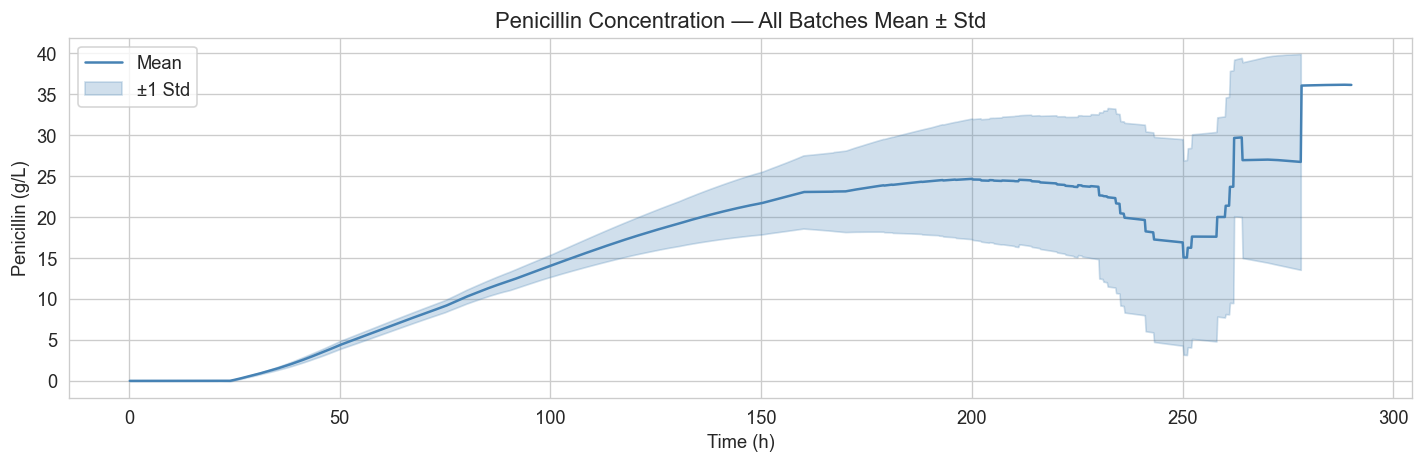

In [8]:
var = 'Penicillin concentration(P:g/L)'
grouped  = df.groupby(TIME_COL)[var]
mean_val = grouped.mean()
std_val  = grouped.std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mean_val.index, mean_val.values, color='steelblue', linewidth=1.5, label='Mean')
ax.fill_between(mean_val.index, mean_val - std_val, mean_val + std_val,
                alpha=0.25, color='steelblue', label='±1 Std')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Penicillin (g/L)')
ax.set_title('Penicillin Concentration — All Batches Mean ± Std')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_penicillin_mean_std.png', bbox_inches='tight')
plt.show()

## 5. 라만 분광 데이터 탐색

In [9]:
# PAT_ref('2-PAT control') 컬럼은 배치 번호(1~100)를 담고 있어 라만 기록 지표로 사용 불가
# 실제 라만 기록 여부: 라만 채널 값이 0인 경우 = 배치 시작 10 타임스텝 워밍업
_raman_ind = raman_cols[0]  # 첫 번째 라만 채널 ('2400')
raman_active_0 = df[_raman_ind].astype(float) != 0
print(f'라만 기록된 행 비율 : {raman_active_0.mean()*100:.1f}% ({raman_active_0.sum():,}/{len(df):,}행)')
print(f'라만 미기록 행       : {(~raman_active_0).sum()} 행 (배치당 첫 10 타임스텝 워밍업)')

라만 기록된 행 비율 : 99.1% (112,935/113,935행)
라만 미기록 행       : 1000 행 (배치당 첫 10 타임스텝 워밍업)


라만 데이터 shape: (112935, 2200)


C:\Users\Admin\AppData\Local\Temp\ipykernel_12340\1106721787.py:32: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\Admin\AppData\Local\Temp\ipykernel_12340\1106721787.py:33: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / '00_raman_spectra.png', bbox_inches='tight')


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


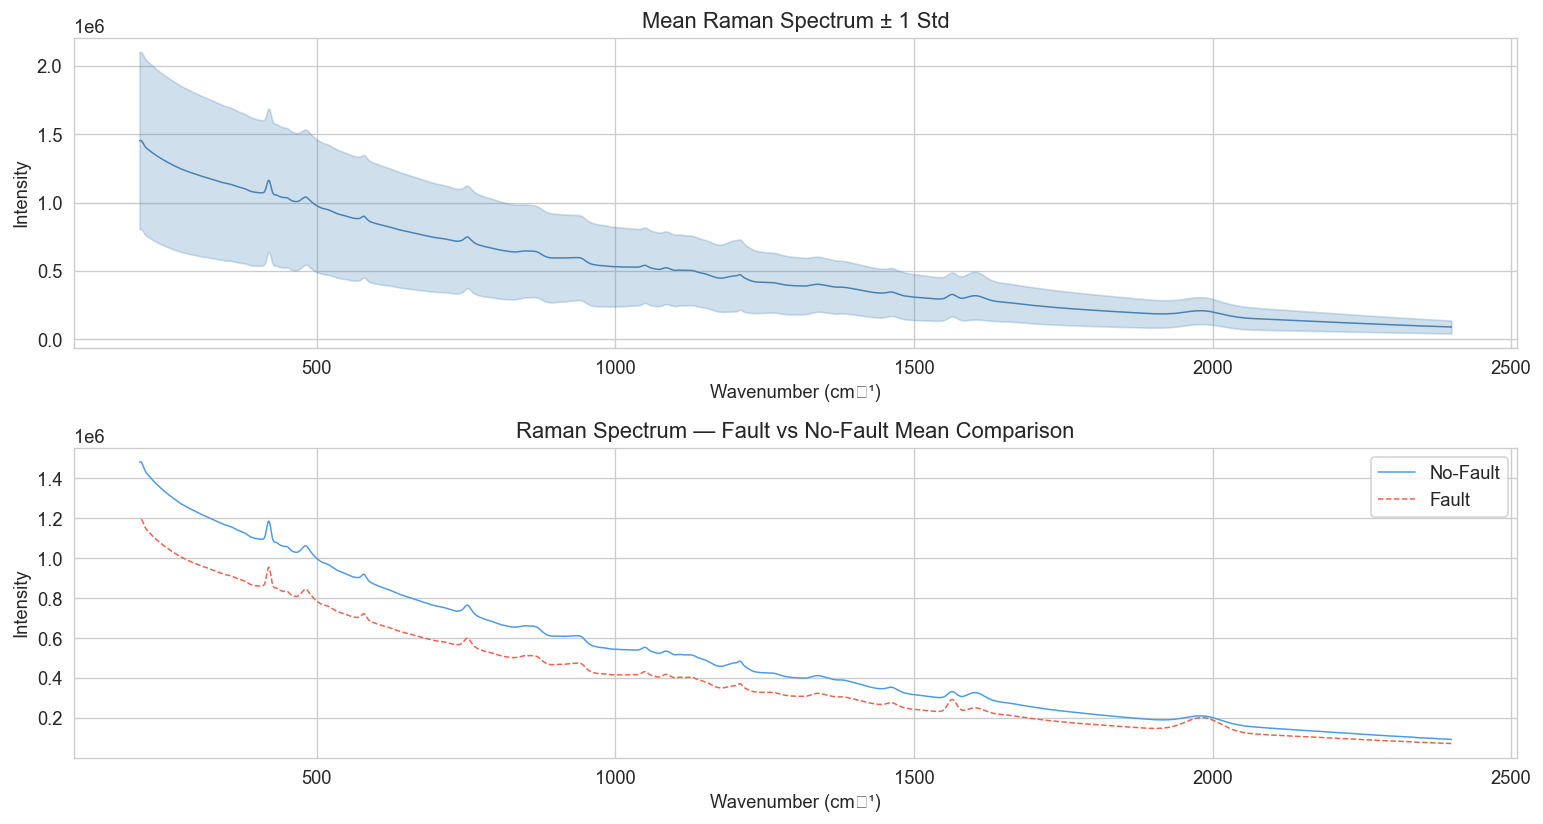

In [10]:
df_raman    = df[df[raman_cols[0]].astype(float) != 0].copy()  # 워밍업 10행 제외
raman_data  = df_raman[raman_cols].astype(float)
wavenumbers = np.array([int(c) for c in raman_cols])

print(f'라만 데이터 shape: {raman_data.shape}')

mean_spectrum = raman_data.mean(axis=0).values
std_spectrum  = raman_data.std(axis=0).values

all_fault_ids    = df_stats[df_stats[FAULT_COL] == 1][BATCH_COL_STATS].astype(int).tolist()
all_no_fault_ids = df_stats[df_stats[FAULT_COL] == 0][BATCH_COL_STATS].astype(int).tolist()

raman_fault    = df_raman[df_raman[BATCH_NUM_COL].isin(all_fault_ids)][raman_cols].mean()
raman_no_fault = df_raman[df_raman[BATCH_NUM_COL].isin(all_no_fault_ids)][raman_cols].mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(wavenumbers, mean_spectrum, color='steelblue', linewidth=0.9)
axes[0].fill_between(wavenumbers, mean_spectrum - std_spectrum, mean_spectrum + std_spectrum,
                     alpha=0.25, color='steelblue')
axes[0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0].set_ylabel('Intensity')
axes[0].set_title('Mean Raman Spectrum ± 1 Std')

axes[1].plot(wavenumbers, raman_no_fault.values, color='#4C9BE8', linewidth=0.9, label='No-Fault')
axes[1].plot(wavenumbers, raman_fault.values,    color='#E8644C', linewidth=0.9, label='Fault', linestyle='--')
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_ylabel('Intensity')
axes[1].set_title('Raman Spectrum — Fault vs No-Fault Mean Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_raman_spectra.png', bbox_inches='tight')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_12340\903963875.py:11: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\Admin\AppData\Local\Temp\ipykernel_12340\903963875.py:12: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(FIGURES_DIR / '00_raman_top20_variance.png', bbox_inches='tight')


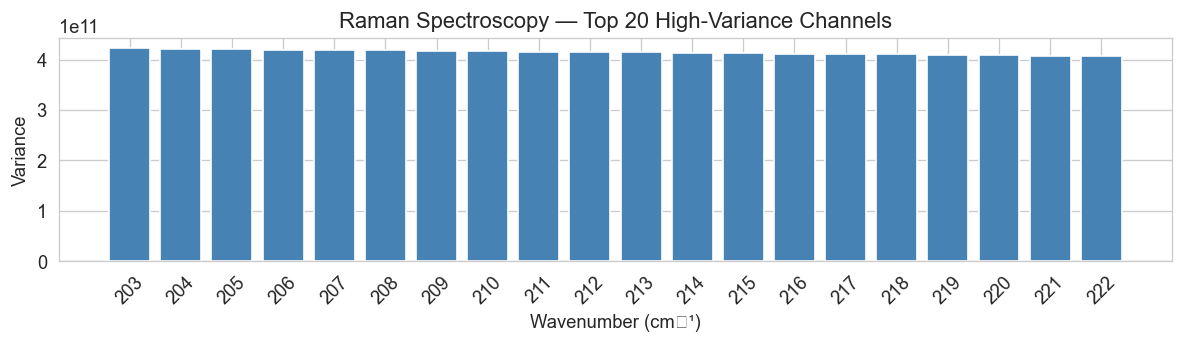

In [11]:
raman_var = raman_data.var(axis=0)
raman_var.index = wavenumbers
top20 = raman_var.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(top20.index.astype(str), top20.values, color='steelblue')
ax.set_xlabel('Wavenumber (cm⁻¹)')
ax.set_ylabel('Variance')
ax.set_title('Raman Spectroscopy — Top 20 High-Variance Channels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_raman_top20_variance.png', bbox_inches='tight')
plt.show()

## 6. 결측치 분석

결측치 있는 공정 변수 수: 5 / 39

Offline Penicillin concentration(P_offline:P(g L^{-1}))    0.981902
Viscosity(Viscosity_offline:centPoise)                     0.981902
Offline Biomass concentratio(X_offline:X(g L^{-1}))        0.981902
NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))    0.981902
PAA concentration offline(PAA_offline:PAA (g L^{-1}))      0.981902


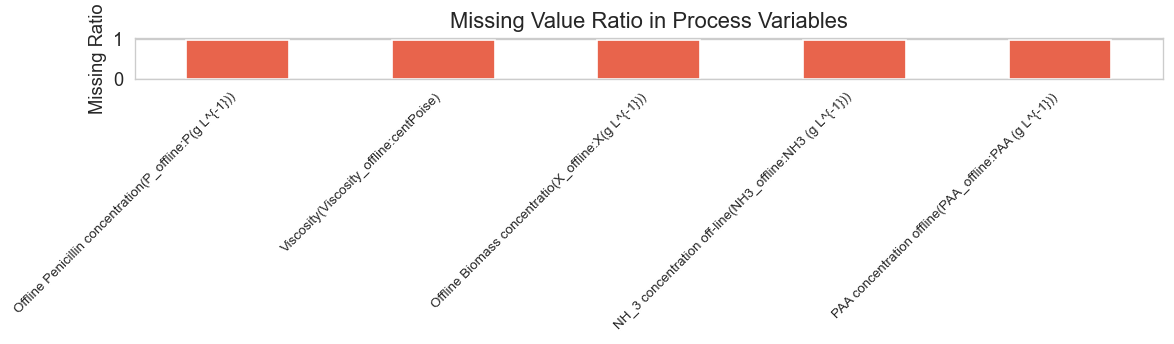

In [12]:
missing = df[process_cols].isnull().mean().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

print(f'결측치 있는 공정 변수 수: {len(missing_nonzero)} / {len(process_cols)}')
print()
print(missing_nonzero.to_string())

if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, 3))
    missing_nonzero.plot(kind='bar', ax=ax, color='#E8644C')
    ax.set_ylabel('Missing Ratio')
    ax.set_title('Missing Value Ratio in Process Variables')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '00_missing_values.png', bbox_inches='tight')
    plt.show()

In [13]:
# 오프라인 변수는 간헐적으로 측정됨
offline_vars = [c for c in process_cols if 'offline' in c.lower() or 'Offline' in c]
print('Offline 변수:', offline_vars)

batch1 = df[df[BATCH_NUM_COL] == 1]
for v in offline_vars[:3]:
    measured = batch1[v].notna().sum()
    print(f'  {v.split("(")[0].strip()}: {measured}/{len(batch1)} 타임스텝에서 측정')

Offline 변수: ['PAA concentration offline(PAA_offline:PAA (g L^{-1}))', 'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))', 'Offline Penicillin concentration(P_offline:P(g L^{-1}))', 'Offline Biomass concentratio(X_offline:X(g L^{-1}))', 'Viscosity(Viscosity_offline:centPoise)']


  PAA concentration offline: 20/1130 타임스텝에서 측정
  NH_3 concentration off-line: 20/1130 타임스텝에서 측정
  Offline Penicillin concentration: 20/1130 타임스텝에서 측정


## 7. Fault vs Normal 배치 비교

Fault 배치 번호: [91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


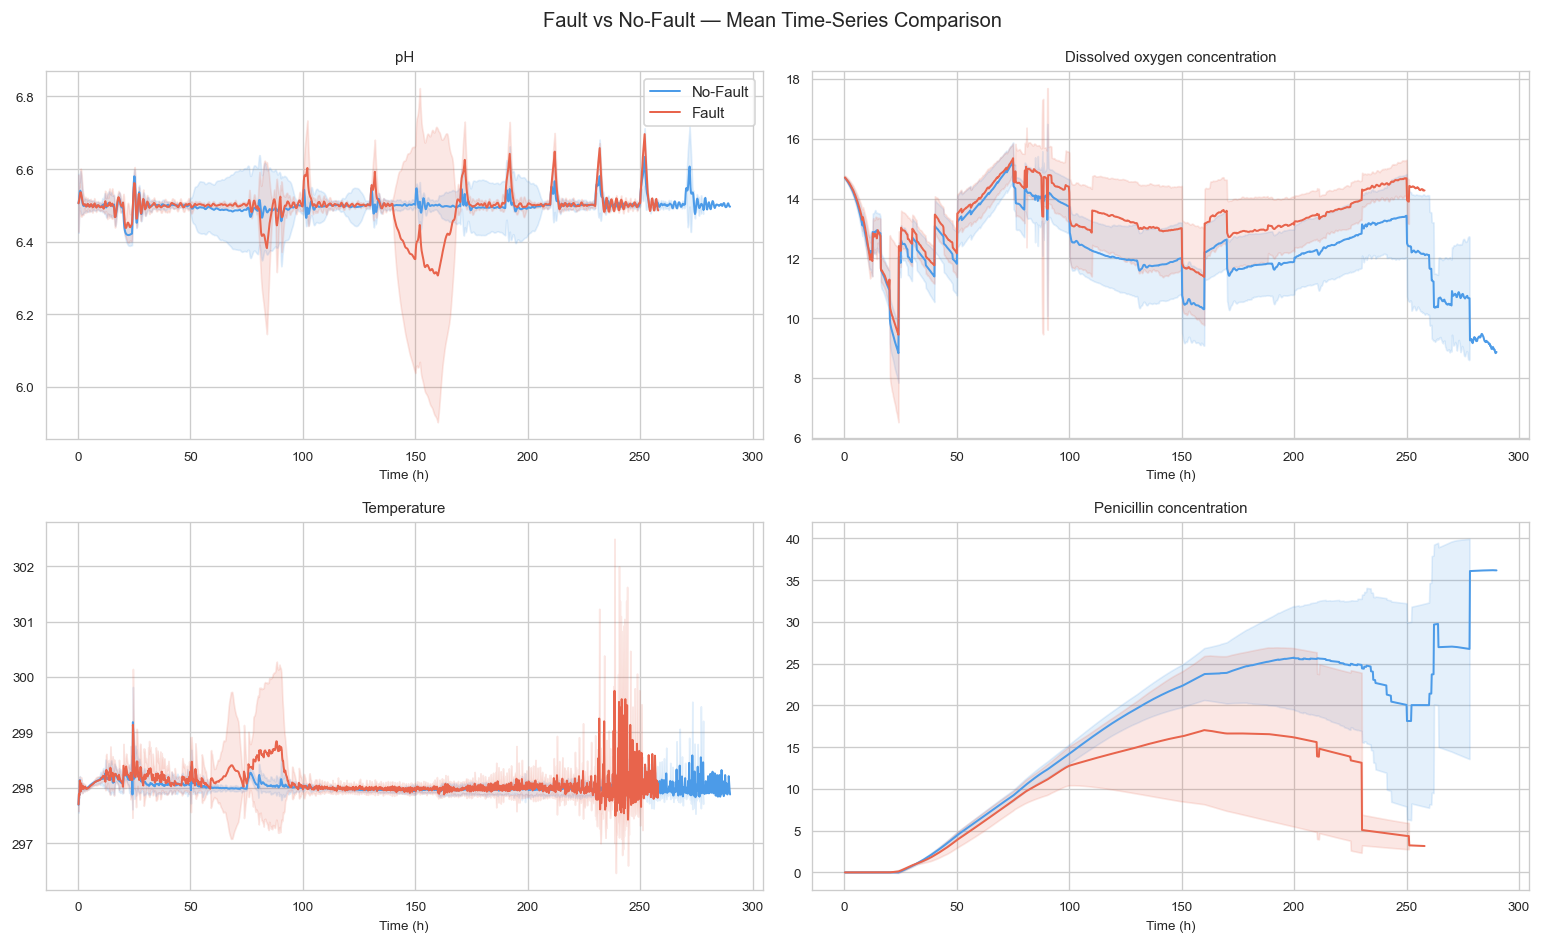

In [14]:
all_fault_ids    = df_stats[df_stats[FAULT_COL] == 1][BATCH_COL_STATS].astype(int).tolist()
all_no_fault_ids = df_stats[df_stats[FAULT_COL] == 0][BATCH_COL_STATS].astype(int).tolist()

print('Fault 배치 번호:', sorted(all_fault_ids))

df_fault    = df[df[BATCH_NUM_COL].isin(all_fault_ids)]
df_no_fault = df[df[BATCH_NUM_COL].isin(all_no_fault_ids)]

compare_vars = [
    'pH(pH:pH)',
    'Dissolved oxygen concentration(DO2:mg/L)',
    'Temperature(T:K)',
    'Penicillin concentration(P:g/L)',
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, var in zip(axes, compare_vars):
    for group, label, color in [
        (df_no_fault, 'No-Fault', '#4C9BE8'),
        (df_fault,    'Fault',    '#E8644C')
    ]:
        mean_t = group.groupby(TIME_COL)[var].mean()
        std_t  = group.groupby(TIME_COL)[var].std()
        ax.plot(mean_t.index, mean_t.values, color=color, linewidth=1.2, label=label)
        ax.fill_between(mean_t.index, mean_t - std_t, mean_t + std_t, alpha=0.15, color=color)
    ax.set_title(var.split('(')[0].strip(), fontsize=9)
    ax.set_xlabel('Time (h)', fontsize=8)
    ax.tick_params(labelsize=8)

axes[0].legend(fontsize=9)
fig.suptitle('Fault vs No-Fault — Mean Time-Series Comparison', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_fault_vs_normal_timeseries.png', bbox_inches='tight')
plt.show()

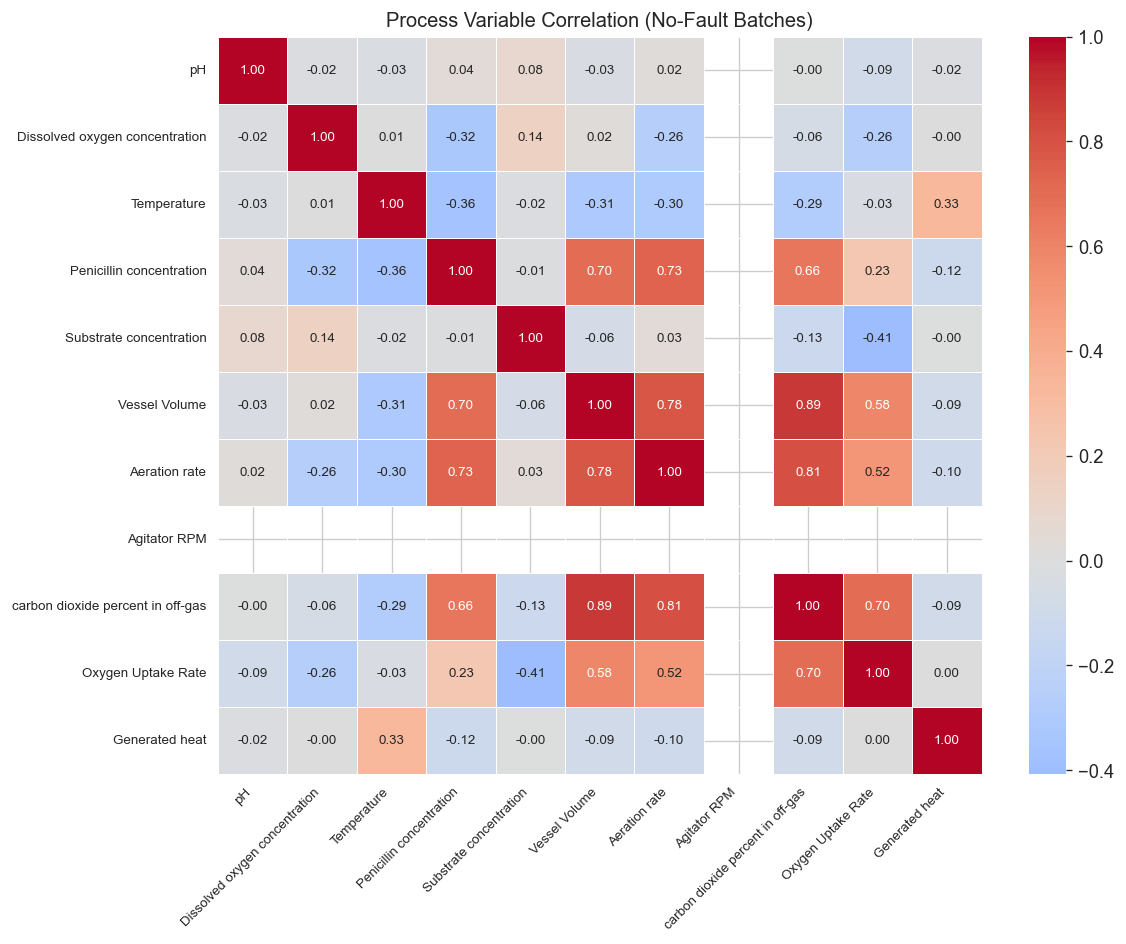

In [15]:
numeric_vars = [
    'pH(pH:pH)',
    'Dissolved oxygen concentration(DO2:mg/L)',
    'Temperature(T:K)',
    'Penicillin concentration(P:g/L)',
    'Substrate concentration(S:g/L)',
    'Vessel Volume(V:L)',
    'Aeration rate(Fg:L/h)',
    'Agitator RPM(RPM:RPM)',
    'carbon dioxide percent in off-gas(CO2outgas:%)',
    'Oxygen Uptake Rate(OUR:(g min^{-1}))',
    'Generated heat(Q:kJ)',
]

corr = df_no_fault[numeric_vars].corr()
short_names = [c.split('(')[0].strip() for c in numeric_vars]
corr.index   = short_names
corr.columns = short_names

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Process Variable Correlation (No-Fault Batches)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 8. 요약 및 연구 방향 메모

In [16]:
_raman_active_summary = df[raman_cols[0]].astype(float) != 0

print('=' * 55)
print('EDA 요약')
print('=' * 55)
print(f'  배치 수           : 100 (Fault: 10개, Normal: 90개)')
print(f'  전체 행 수        : {len(df):,}')
print(f'  공정 변수 수       : {len(process_cols)}')
print(f'  라만 분광 채널 수   : {len(raman_cols)} (201~2400 cm⁻¹)')
print(f'  라만 기록 비율     : {_raman_active_summary.mean()*100:.1f}%')
print(f'  수율 평균          : {df_stats[YIELD_COL].mean():,.0f} kg')
print(f'  수율 표준편차      : {df_stats[YIELD_COL].std():,.0f} kg')
print('=' * 55)

EDA 요약
  배치 수           : 100 (Fault: 10개, Normal: 90개)
  전체 행 수        : 113,935
  공정 변수 수       : 39
  라만 분광 채널 수   : 2200 (201~2400 cm⁻¹)
  라만 기록 비율     : 99.1%
  수율 평균          : 3,029,064 kg
  수율 표준편차      : 750,817 kg


### 관찰 사항 (EDA 실행 후 직접 기록)

- [ ] Fault 배치와 Normal 배치 간 어떤 변수에서 가장 큰 차이가 관찰되었는가?
- [ ] 라만 분광에서 분산이 큰 채널은 어떤 물질과 연관될 수 있는가?
- [ ] 오프라인 측정 변수의 결측 패턴이 연구에 어떤 영향을 주는가?
- [ ] 배치 간 타임스텝 수 차이가 있는가? 있다면 정렬(alignment) 전략이 필요한가?

### 잠재적 연구 주제

- **주제 A**: 라만 분광 기반 페니실린 농도 소프트 센서 (Soft Sensor)
- **주제 B**: 딥러닝 기반 이상 감지 (Anomaly Detection) — LSTM-AE, Transformer-AE
- **주제 C**: 멀티모달 융합 (공정 변수 + 라만) 기반 수율 예측
- **주제 D**: 배치 공정 모니터링 — MSPC (PCA 기반) vs 딥러닝 비교

> 연구 주제는 EDA 관찰 결과를 바탕으로 확정할 것.